In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score, roc_auc_score
from joblib import Parallel, delayed
import time
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
    

from data_prep import create_artificial_dataset, load_spambase, load_sonar, load_breast_cancer_data, load_ionosphere
from missingness import MissingDataGenerator
from fista import FISTA
from unlabeled import UnlabeledLogReg

In [23]:
artificial_X, artificial_y = create_artificial_dataset()
spambase_X, spambase_y = load_spambase()
sonar_X, sonar_y = load_sonar()
breast_X, breast_y = load_breast_cancer_data()
ionosphere_X, ionosphere_y = load_ionosphere()

Artificial dataset prepared: X shape (2000, 50), y shape (2000,), dropped collinear features: 0
Loading Spambase dataset...
Spambase loaded: X shape (4601, 56), y shape (4601,), dropped collinear features: 1
Loading Sonar dataset...
Sonar loaded: X shape (208, 60), y shape (208,), dropped collinear features: 0
Loading Breast Cancer dataset...
Breast Cancer loaded: X shape (569, 23), y shape (569,), dropped collinear features: 7
Positive labels (1s): 357 out of 569
Loading Ionosphere dataset...
Ionosphere loaded: X shape (351, 34), y shape (351,), dropped collinear features: 0


# Experiments
Comparison of methods under different label-missingness mechanisms.

In [24]:
datasets = {
    "Artificial": (artificial_X, artificial_y),
    "Spambase": (spambase_X, spambase_y),
    "Sonar": (sonar_X, sonar_y),
    "BreastCancer": (breast_X, breast_y),
    "Ionosphere": (ionosphere_X, ionosphere_y)
}

def evaluate_metrics(model, X_test, y_test):
    """Compute evaluation metrics on the test set."""
    preds = model.predict(X_test)
    probas = model.predict_proba(X_test)[:, 1]
    return {
        "Accuracy": accuracy_score(y_test, preds),
        "Balanced_Acc": balanced_accuracy_score(y_test, preds),
        "F1": f1_score(y_test, preds, zero_division=0),
        "ROC_AUC": roc_auc_score(y_test, probas)
    }

def run_single_scheme_experiment(dataset_name, X, y, scheme_name):
    """Run all methods for one dataset and one missingness scheme."""
    X_train, X_test, y_train_true, y_test_true = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    if scheme_name == "MCAR":
        X_train, y_train_obs = MissingDataGenerator.apply_mcar(
            X_train, y_train_true, c=0.3, random_state=42
        )
    elif scheme_name == "MAR1":
        X_train, y_train_obs = MissingDataGenerator.apply_mar1(
            X_train, y_train_true, random_state=42
        )
    elif scheme_name == "MAR2":
        X_train, y_train_obs = MissingDataGenerator.apply_mar2(
            X_train, y_train_true, random_state=42
        )
    elif scheme_name == "MNAR":
        X_train, y_train_obs = MissingDataGenerator.apply_mnar(
            X_train, y_train_true, random_state=42
        )
    else:
        raise ValueError(f"Unknown scheme: {scheme_name}")

    results = []
    base_lambda = [0.01]

    oracle = FISTA(lambdas=base_lambda).fit(X_train, y_train_true)
    res_oracle = evaluate_metrics(oracle, X_test, y_test_true)
    res_oracle.update({"Dataset": dataset_name, "Scheme": scheme_name, "Model": "Oracle"})
    results.append(res_oracle)

    naive_mask = y_train_obs != -1
    naive = FISTA(lambdas=base_lambda).fit(X_train[naive_mask], y_train_obs[naive_mask])
    res_naive = evaluate_metrics(naive, X_test, y_test_true)
    res_naive.update({"Dataset": dataset_name, "Scheme": scheme_name, "Model": "Naive"})
    results.append(res_naive)

    pseudo = UnlabeledLogReg(model=FISTA(lambdas=base_lambda), method="pseudo_labeling")
    pseudo.fit(X_train, y_train_obs)
    res_pseudo = evaluate_metrics(pseudo, X_test, y_test_true)
    res_pseudo.update({"Dataset": dataset_name, "Scheme": scheme_name, "Model": "Pseudo-Labeling"})
    results.append(res_pseudo)

    em = UnlabeledLogReg(model=FISTA(lambdas=base_lambda), method="em")
    em.fit(X_train, y_train_obs)
    res_em = evaluate_metrics(em, X_test, y_test_true)
    res_em.update({"Dataset": dataset_name, "Scheme": scheme_name, "Model": "Soft-EM"})
    results.append(res_em)

    return results

In [25]:
print("Experiment 1: schemes comparison")
start_time = time.time()

schemes = ["MCAR", "MAR1", "MAR2", "MNAR"]
tasks = []
for data_name, (X, y) in datasets.items():
    for scheme in schemes:
        tasks.append((data_name, X, y, scheme))

all_results = Parallel(n_jobs=-1)(
    delayed(run_single_scheme_experiment)(d_name, X, y, sch)
    for d_name, X, y, sch in tasks
)

flat_results = [item for sublist in all_results for item in sublist]
df_experiment1 = pd.DataFrame(flat_results)
df_experiment1 = df_experiment1[["Dataset", "Scheme", "Model", "Accuracy", "Balanced_Acc", "F1", "ROC_AUC"]]

elapsed = time.time() - start_time
print(f"Experiment 1 completed in {elapsed:.2f} seconds")
display(df_experiment1.groupby(["Dataset", "Scheme", "Model"]).mean().round(4))

Experiment 1: schemes comparison
Experiment 1 completed in 250.31 seconds


Accuracy  Balanced_Acc      F1  ROC_AUC
Dataset    Scheme Model                                                   
Artificial MAR1   Naive              0.8575        0.8573  0.8535   0.9286
                  Oracle             0.8700        0.8700  0.8680   0.9428
                  Pseudo-Labeling    0.8575        0.8575  0.8550   0.9274
                  Soft-EM            0.8550        0.8549  0.8520   0.9282
           MAR2   Naive              0.8625        0.8627  0.8615   0.9320
...                                     ...           ...     ...      ...
Spambase   MCAR   Soft-EM            0.8740        0.8799  0.8606   0.9385
           MNAR   Naive              0.8730        0.8711  0.8513   0.9208
                  Oracle             0.7785        0.8072  0.7918   0.8874
                  Pseudo-Labeling    0.8165        0.8184  0.7931   0.8367
                  Soft-EM            0.7600        0.7368  0.6736   0.7520

[80 rows x 4 columns]

### Experiment 2: preparation
This step initializes helper utilities and experiment configuration for the c-sweep under MCAR.

In [26]:
from itertools import combinations
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import precision_score, recall_score


def to_numpy_local(data):
    if hasattr(data, "to_numpy"):
        return data.to_numpy()
    return np.asarray(data)


def safe_roc_auc_local(y_true, y_prob):
    if len(np.unique(y_true)) < 2:
        return np.nan
    return roc_auc_score(y_true, y_prob)


def evaluate_full_metrics(y_true, y_pred, y_prob):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "Balanced_Acc": balanced_accuracy_score(y_true, y_pred),
        "ROC_AUC": safe_roc_auc_local(y_true, y_prob),
    }


c_values = [0.1, 0.3, 0.5, 0.7, 0.9]
sweep_datasets = ["BreastCancer", "Spambase", "Ionosphere", "Sonar"]
model_order = ["Oracle", "sklearn L1", "Naive", "Pseudo-Labeling", "Soft-EM"]
metric_order = ["Accuracy", "Precision", "Recall", "F1", "Balanced_Acc", "ROC_AUC"]
n_runs = 3

metric_records = []
pairwise_records = []

### Experiment 2: run the c-sweep
This step executes all model runs for each dataset and each c value, then aggregates results into summary tables.

In [27]:
for dataset_name in sweep_datasets:
    X = to_numpy_local(datasets[dataset_name][0])
    y = to_numpy_local(datasets[dataset_name][1]).astype(int)

    for run_idx in range(n_runs):
        seed = 100 + run_idx
        X_train, X_test, y_train_true, y_test_true = train_test_split(
            X, y, test_size=0.2, random_state=seed, stratify=y
        )

        for c in c_values:
            _, y_train_obs = MissingDataGenerator.apply_mcar(
                X_train, y_train_true, c=c, random_state=seed
            )
            y_train_obs = np.asarray(y_train_obs)
            observed_mask = y_train_obs != -1

            models = {}
            oracle = FISTA(lambdas=[0.01], max_iter=300)
            oracle.fit(X_train, y_train_true)
            models["Oracle"] = oracle

            sklearn_l1 = make_pipeline(
                StandardScaler(),
                LogisticRegression(
                    penalty="l1",
                    solver="saga",
                    C=100.0,
                    max_iter=5000,
                    random_state=seed,
                ),
            )
            sklearn_l1.fit(X_train, y_train_true)
            models["sklearn L1"] = sklearn_l1

            if observed_mask.sum() >= 5 and len(np.unique(y_train_obs[observed_mask])) > 1:
                naive = FISTA(lambdas=[0.01], max_iter=300)
                naive.fit(X_train[observed_mask], y_train_obs[observed_mask])
            else:
                naive = FISTA(lambdas=[0.01], max_iter=300)
                naive.fit(X_train, y_train_true)
            models["Naive"] = naive

            pseudo = UnlabeledLogReg(model=FISTA(lambdas=[0.01], max_iter=300), method="pseudo_labeling")
            pseudo.fit(X_train, y_train_obs)
            models["Pseudo-Labeling"] = pseudo

            soft_em = UnlabeledLogReg(model=FISTA(lambdas=[0.01], max_iter=300), method="em")
            soft_em.fit(X_train, y_train_obs)
            models["Soft-EM"] = soft_em

            pred_cache = {}
            prob_cache = {}

            for model_name in model_order:
                model = models[model_name]
                y_pred = model.predict(X_test)
                y_prob = model.predict_proba(X_test)[:, 1]
                pred_cache[model_name] = y_pred
                prob_cache[model_name] = y_prob

                metrics = evaluate_full_metrics(y_test_true, y_pred, y_prob)
                metric_records.append(
                    {
                        "Dataset": dataset_name,
                        "Run": run_idx,
                        "c_value": c,
                        "Model": model_name,
                        "Observed_Label_Fraction": float(np.mean(observed_mask)),
                        **metrics,
                    }
                )

            for model_a, model_b in combinations(model_order, 2):
                pred_a = pred_cache[model_a]
                pred_b = pred_cache[model_b]
                prob_a = prob_cache[model_a]
                prob_b = prob_cache[model_b]

                if np.std(prob_a) > 0 and np.std(prob_b) > 0:
                    prob_corr = float(np.corrcoef(prob_a, prob_b)[0, 1])
                else:
                    prob_corr = np.nan

                pairwise_records.append(
                    {
                        "Dataset": dataset_name,
                        "Run": run_idx,
                        "c_value": c,
                        "model_a": model_a,
                        "model_b": model_b,
                        "agreement": float(np.mean(pred_a == pred_b)),
                        "disagreement_count": int(np.sum(pred_a != pred_b)),
                        "prob_correlation": prob_corr,
                    }
                )

df_c_metrics = pd.DataFrame(metric_records)
df_c_pairwise = pd.DataFrame(pairwise_records)

mean_metrics = (
    df_c_metrics.groupby(["Dataset", "c_value", "Model"], as_index=False)[metric_order]
    .mean()
    .sort_values(["Dataset", "c_value", "Model"])
)

std_metrics = (
    df_c_metrics.groupby(["Dataset", "c_value", "Model"], as_index=False)[metric_order]
    .std()
    .sort_values(["Dataset", "c_value", "Model"])
)

print("Extended c-sweep summary (means):")
display(mean_metrics.head(30))
print("Extended c-sweep summary (std):")
display(std_metrics.head(30))

C:\Users\anost\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\anost\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
C:\Users\anost\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penal

Extended c-sweep summary (means):


,Dataset,c_value,Model,Accuracy,Precision,Recall,F1,Balanced_Acc,ROC_AUC
0,BreastCancer,0.1,Naive,0.707602,0.823972,0.717593,0.748557,0.704034,0.851521
1,BreastCancer,0.1,Oracle,0.716374,0.899293,0.620370,0.734171,0.750661,0.873787
2,BreastCancer,0.1,Pseudo-Labeling,0.684211,0.811812,0.699074,0.725478,0.678902,0.837853
3,BreastCancer,0.1,Soft-EM,0.839181,0.888659,0.856481,0.869024,0.833003,0.914462
4,BreastCancer,0.1,sklearn L1,0.956140,0.971831,0.958333,0.965035,0.955357,0.983796
5,BreastCancer,0.3,Naive,0.733918,0.897757,0.652778,0.755808,0.762897,0.872024
6,BreastCancer,0.3,Oracle,0.716374,0.899293,0.620370,0.734171,0.750661,0.873787
7,BreastCancer,0.3,Pseudo-Labeling,0.669591,0.880841,0.550926,0.676746,0.711971,0.847663
8,BreastCancer,0.3,Soft-EM,0.809942,0.856950,0.856481,0.851387,0.793320,0.895723
9,BreastCancer,0.3,sklearn L1,0.956140,0.971831,0.958333,0.965035,0.955357,0.983796


Extended c-sweep summary (std):


,Dataset,c_value,Model,Accuracy,Precision,Recall,F1,Balanced_Acc,ROC_AUC
0,BreastCancer,0.1,Naive,0.035451,0.096689,0.199504,0.065521,0.054612,0.027927
1,BreastCancer,0.1,Oracle,0.036520,0.040882,0.032075,0.035151,0.038542,0.030282
2,BreastCancer,0.1,Pseudo-Labeling,0.026316,0.104784,0.236655,0.073426,0.055718,0.021330
3,BreastCancer,0.1,Soft-EM,0.045014,0.044578,0.098536,0.044379,0.039562,0.017292
4,BreastCancer,0.1,sklearn L1,0.017544,0.014085,0.013889,0.013986,0.018849,0.012001
5,BreastCancer,0.3,Naive,0.035451,0.030489,0.036747,0.034595,0.035312,0.028963
6,BreastCancer,0.3,Oracle,0.036520,0.040882,0.032075,0.035151,0.038542,0.030282
7,BreastCancer,0.3,Pseudo-Labeling,0.039555,0.015071,0.062628,0.051147,0.031627,0.029916
8,BreastCancer,0.3,Soft-EM,0.039555,0.092432,0.076494,0.019655,0.076885,0.027638
9,BreastCancer,0.3,sklearn L1,0.017544,0.014085,0.013889,0.013986,0.018849,0.012001


### Experiment 2: global metric trends
This step visualizes all tracked metrics as a function of the missing-label ratio c.

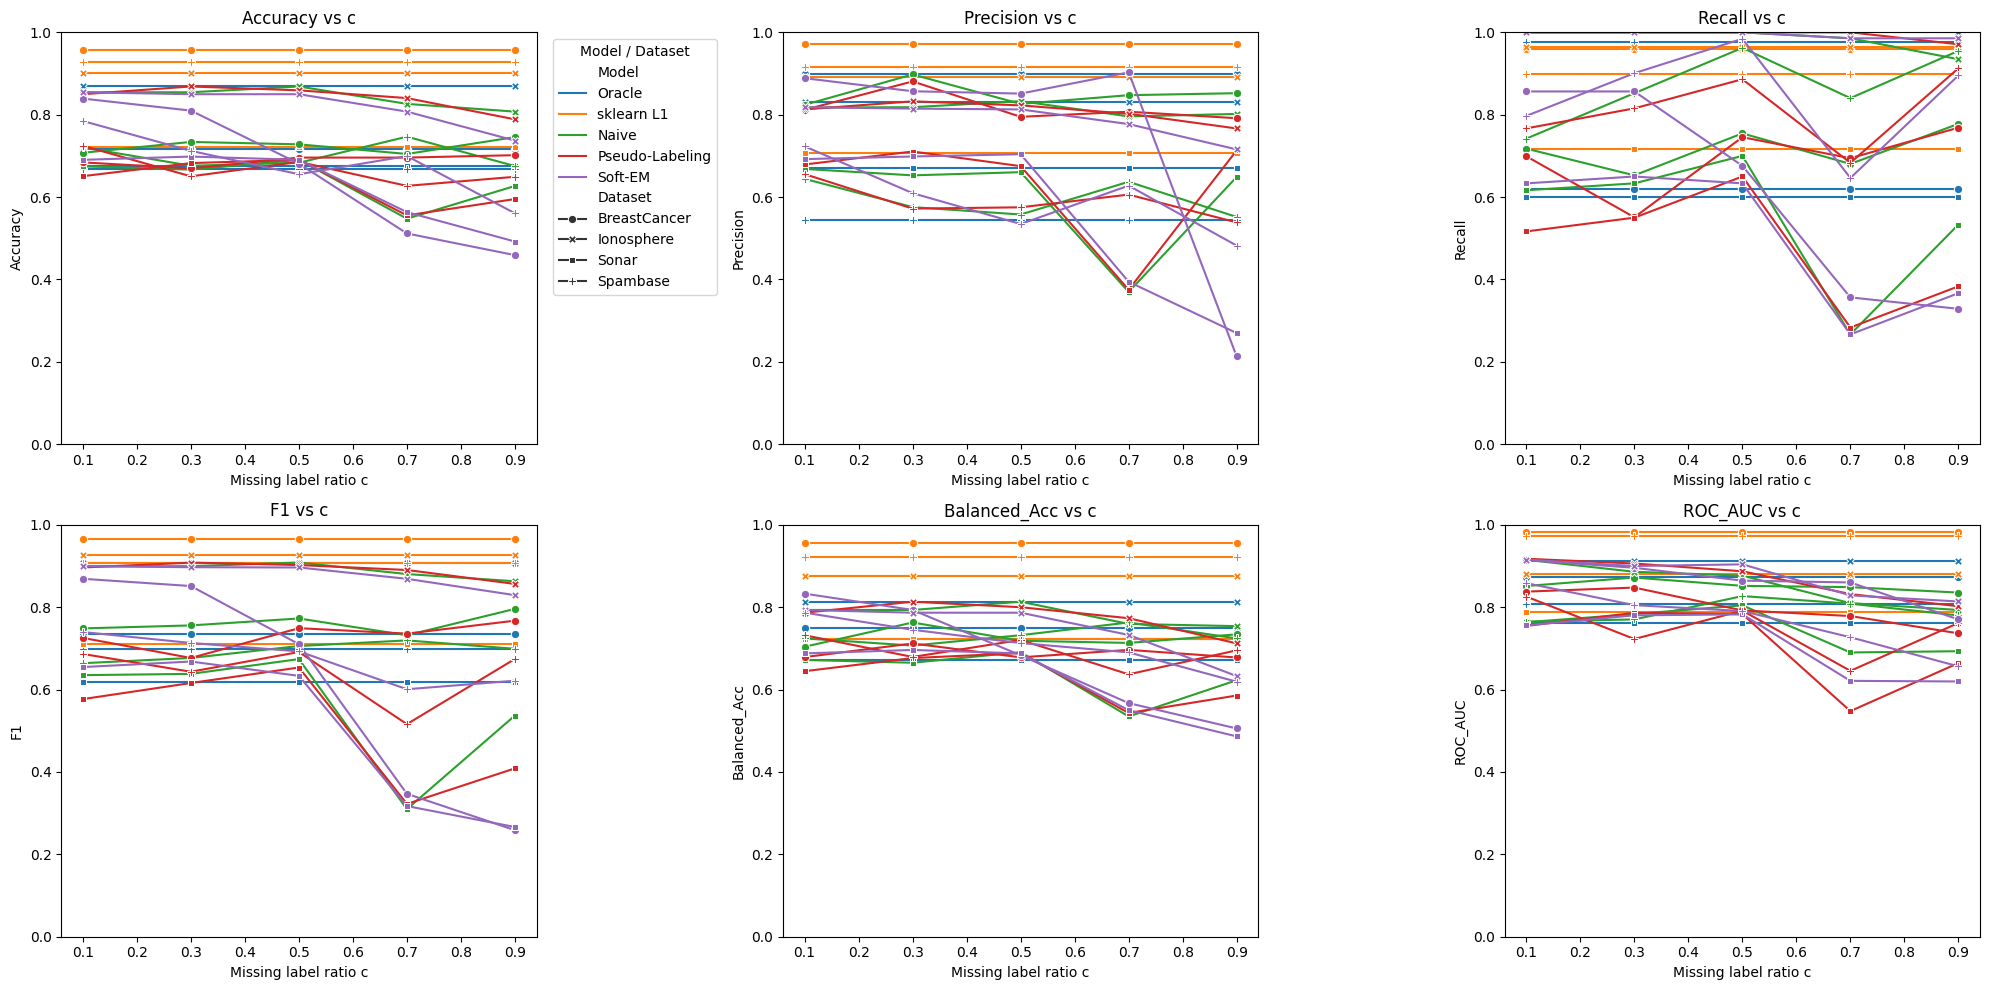

In [28]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()

for idx, metric_name in enumerate(metric_order):
    sns.lineplot(
        data=mean_metrics,
        x="c_value",
        y=metric_name,
        hue="Model",
        hue_order=model_order,
        style="Dataset",
        markers=True,
        dashes=False,
        ax=axes[idx],
    )
    axes[idx].set_title(f"{metric_name} vs c")
    axes[idx].set_xlabel("Missing label ratio c")
    axes[idx].set_ylabel(metric_name)
    axes[idx].set_ylim(0.0, 1.0)

    if idx != 0 and axes[idx].legend_ is not None:
        axes[idx].legend_.remove()

if axes[0].legend_ is not None:
    axes[0].legend(title="Model / Dataset", bbox_to_anchor=(1.02, 1.0), loc="upper left")

plt.tight_layout()
plt.show()

### Experiment 2: per-dataset detailed view
This step shows F1, ROC AUC, and Balanced Accuracy trends for each dataset separately.

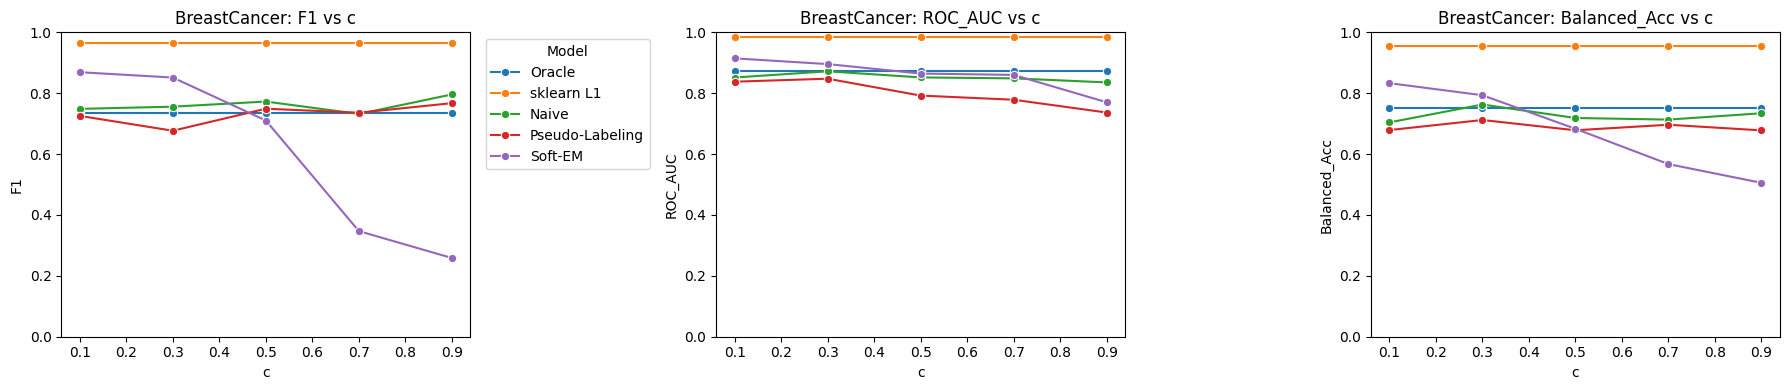

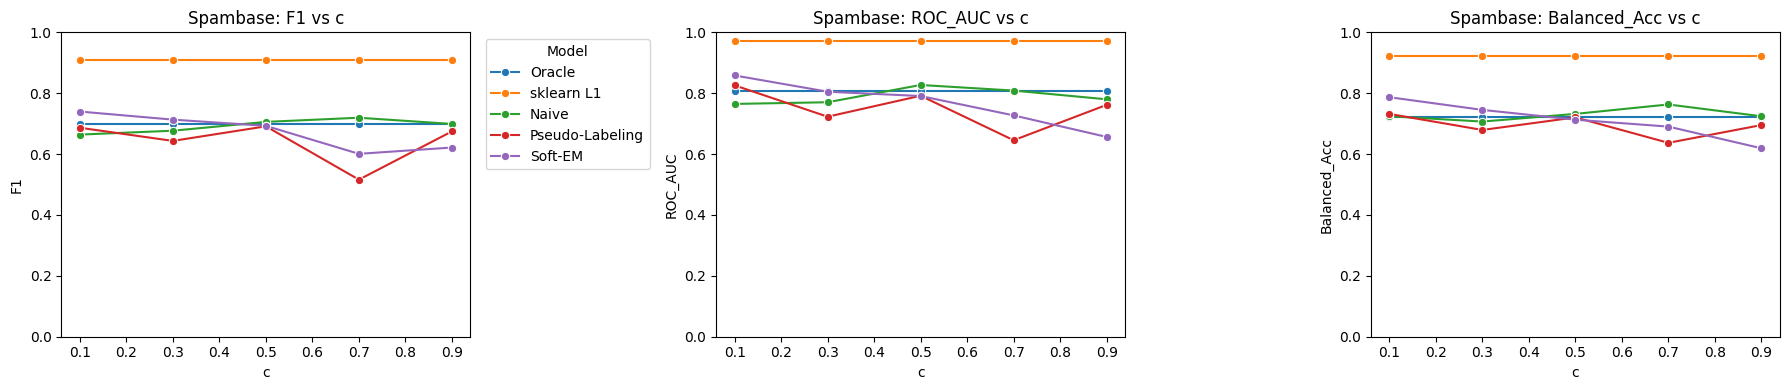

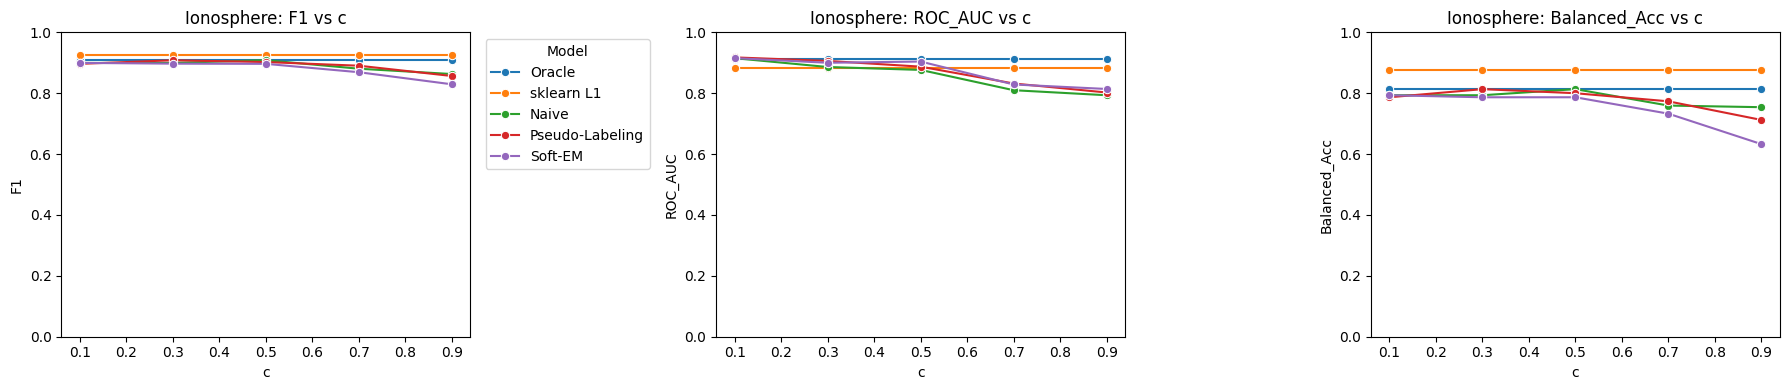

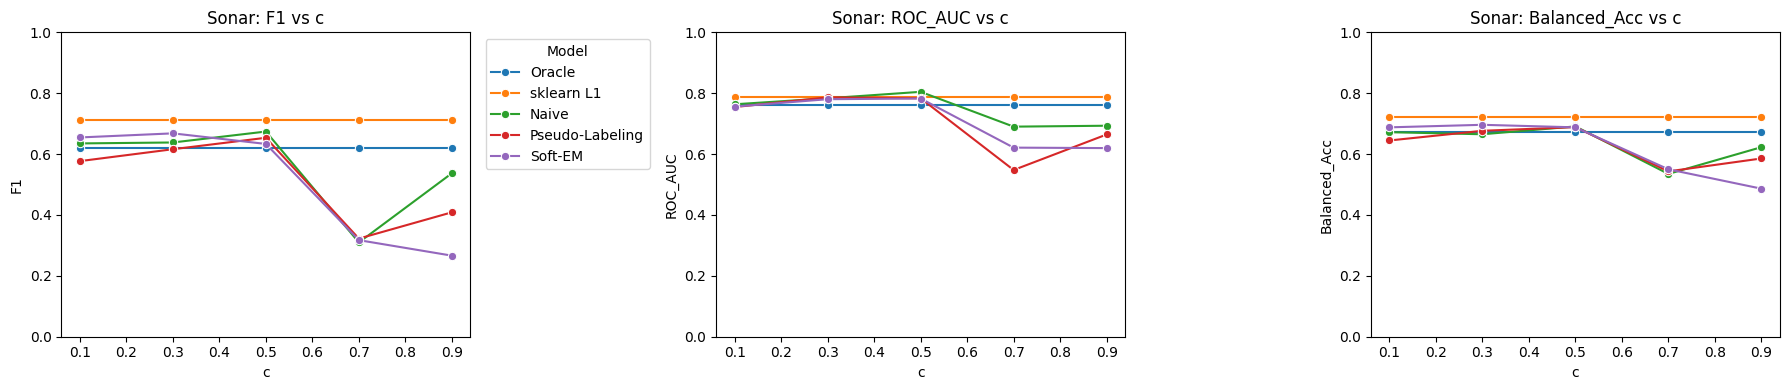

In [29]:
focus_metrics = ["F1", "ROC_AUC", "Balanced_Acc"]
for dataset_name in sweep_datasets:
    subset = mean_metrics[mean_metrics["Dataset"] == dataset_name]
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    for idx, metric_name in enumerate(focus_metrics):
        sns.lineplot(
            data=subset,
            x="c_value",
            y=metric_name,
            hue="Model",
            hue_order=model_order,
            marker="o",
            ax=axes[idx],
        )
        axes[idx].set_title(f"{dataset_name}: {metric_name} vs c")
        axes[idx].set_xlabel("c")
        axes[idx].set_ylabel(metric_name)
        axes[idx].set_ylim(0.0, 1.0)
        if idx != 0 and axes[idx].legend_ is not None:
            axes[idx].legend_.remove()
    if axes[0].legend_ is not None:
        axes[0].legend(title="Model", bbox_to_anchor=(1.02, 1.0), loc="upper left")
    plt.tight_layout()
    plt.show()

### Experiment 2: robustness and agreement analysis
This step computes robustness scores, pairwise agreement trends, and an agreement heatmap at c = 0.9.

Robustness ranking (higher AUC is better, slope closer to 0 is more stable):


,Dataset,Model,Metric,Robustness_AUC,Slope_vs_c
24,BreastCancer,sklearn L1,Accuracy,0.956140,-1.748973e-16
0,BreastCancer,Naive,Accuracy,0.723319,2.339181e-02
6,BreastCancer,Oracle,Accuracy,0.716374,1.748848e-16
12,BreastCancer,Pseudo-Labeling,Accuracy,0.688596,3.070175e-02
18,BreastCancer,Soft-EM,Accuracy,0.663012,-5.292398e-01
28,BreastCancer,sklearn L1,Balanced_Acc,0.955357,2.771037e-16
10,BreastCancer,Oracle,Balanced_Acc,0.750661,2.803003e-16
4,BreastCancer,Naive,Balanced_Acc,0.728464,5.291005e-03
16,BreastCancer,Pseudo-Labeling,Balanced_Acc,0.691262,-8.763228e-03
22,BreastCancer,Soft-EM,Balanced_Acc,0.678241,-4.404762e-01


Pairwise agreement summary:


,Dataset,c_value,model_a,model_b,agreement_mean,disagreement_mean,prob_corr_mean
0,BreastCancer,0.1,Naive,Pseudo-Labeling,0.959064,4.666667,0.994452
1,BreastCancer,0.1,Naive,Soft-EM,0.833333,19.000000,0.889703
2,BreastCancer,0.1,Oracle,Naive,0.862573,15.666667,0.951215
3,BreastCancer,0.1,Oracle,Pseudo-Labeling,0.821637,20.333333,0.935793
4,BreastCancer,0.1,Oracle,Soft-EM,0.801170,22.666667,0.885426
5,BreastCancer,0.1,Oracle,sklearn L1,0.725146,31.333333,0.612680
6,BreastCancer,0.1,Pseudo-Labeling,Soft-EM,0.804094,22.333333,0.856113
7,BreastCancer,0.1,sklearn L1,Naive,0.710526,33.000000,0.572519
8,BreastCancer,0.1,sklearn L1,Pseudo-Labeling,0.675439,37.000000,0.534516
9,BreastCancer,0.1,sklearn L1,Soft-EM,0.847953,17.333333,0.742739


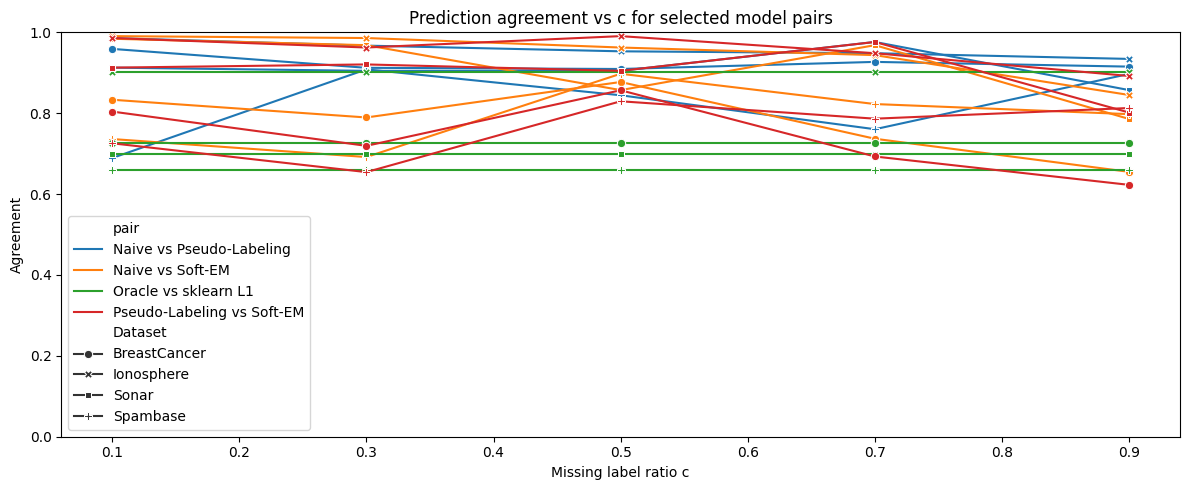

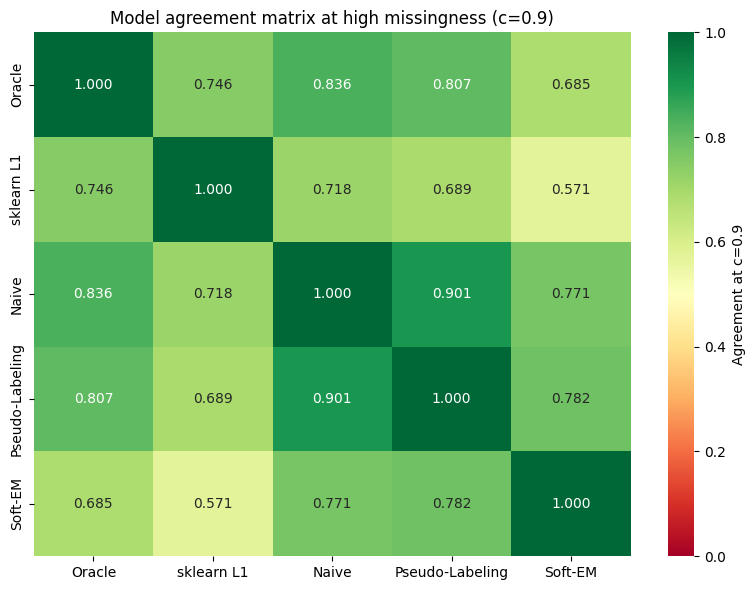

In [30]:
robustness_rows = []
for (dataset_name, model_name), group in mean_metrics.groupby(["Dataset", "Model"]):
    group = group.sort_values("c_value")
    c_grid = group["c_value"].to_numpy()

    for metric_name in metric_order:
        values = group[metric_name].to_numpy()
        robustness_auc = float(np.trapezoid(values, c_grid) / (c_grid.max() - c_grid.min()))
        slope = float(np.polyfit(c_grid, values, 1)[0])
        robustness_rows.append(
            {
                "Dataset": dataset_name,
                "Model": model_name,
                "Metric": metric_name,
                "Robustness_AUC": robustness_auc,
                "Slope_vs_c": slope,
            }
        )

robustness_df = pd.DataFrame(robustness_rows).sort_values(
    ["Dataset", "Metric", "Robustness_AUC"], ascending=[True, True, False]
)
print("Robustness ranking (higher AUC is better, slope closer to 0 is more stable):")
display(robustness_df.head(40))

pairwise_summary = (
    df_c_pairwise.groupby(["Dataset", "c_value", "model_a", "model_b"], as_index=False)
    .agg(
        agreement_mean=("agreement", "mean"),
        disagreement_mean=("disagreement_count", "mean"),
        prob_corr_mean=("prob_correlation", "mean"),
    )
)

print("Pairwise agreement summary:")
display(pairwise_summary.head(30))

pairwise_summary["pair"] = pairwise_summary["model_a"] + " vs " + pairwise_summary["model_b"]
focus_pairs = pairwise_summary[
    pairwise_summary["pair"].isin(
        [
            "Pseudo-Labeling vs Soft-EM",
            "Naive vs Soft-EM",
            "Naive vs Pseudo-Labeling",
            "Oracle vs sklearn L1",
        ]
    )
]

plt.figure(figsize=(12, 5))
sns.lineplot(
    data=focus_pairs,
    x="c_value",
    y="agreement_mean",
    hue="pair",
    style="Dataset",
    markers=True,
    dashes=False,
)
plt.title("Prediction agreement vs c for selected model pairs")
plt.xlabel("Missing label ratio c")
plt.ylabel("Agreement")
plt.ylim(0.0, 1.0)
plt.tight_layout()
plt.show()

heat_c = 0.9
heat_src = pairwise_summary[pairwise_summary["c_value"] == heat_c]
heat_avg = (
    heat_src.groupby(["model_a", "model_b"], as_index=False)
    .agg(agreement_mean=("agreement_mean", "mean"))
)

model_matrix = pd.DataFrame(1.0, index=model_order, columns=model_order, dtype=float)
for row in heat_avg.itertuples(index=False):
    model_matrix.loc[row.model_a, row.model_b] = row.agreement_mean
    model_matrix.loc[row.model_b, row.model_a] = row.agreement_mean

plt.figure(figsize=(8, 6))
sns.heatmap(
    model_matrix,
    annot=True,
    fmt=".3f",
    cmap="RdYlGn",
    vmin=0,
    vmax=1,
    cbar_kws={"label": f"Agreement at c={heat_c}"},
)
plt.title(f"Model agreement matrix at high missingness (c={heat_c})")
plt.tight_layout()
plt.show()

Task 2: lambda validation and coefficient paths
Fitting FISTA on lambda grid
Best lambda: 0.0001


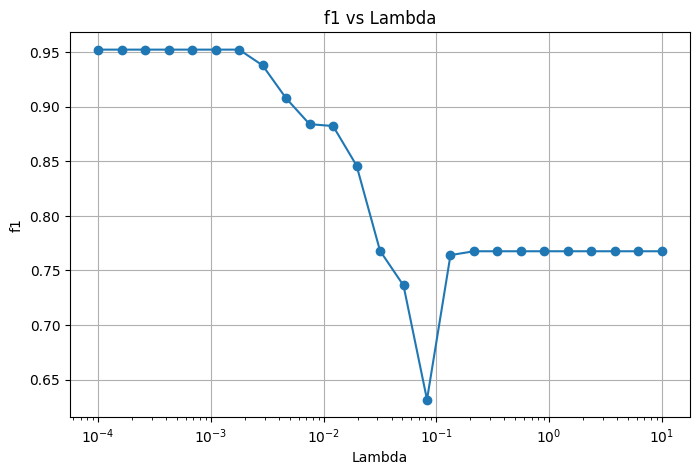

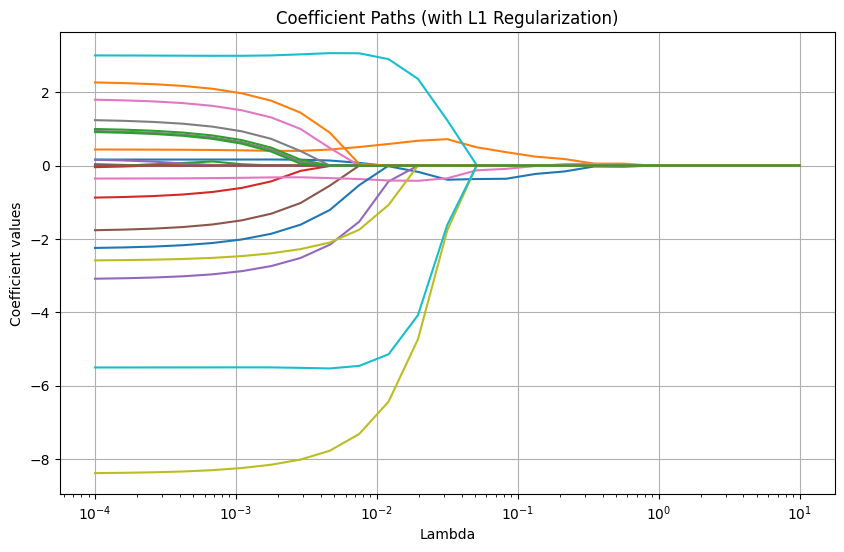

In [31]:
print("Task 2: lambda validation and coefficient paths")

X_bc, y_bc = datasets["BreastCancer"]
X_train, X_val, y_train, y_val = train_test_split(
    X_bc, y_bc, test_size=0.2, random_state=42
)

lambda_grid = np.logspace(-4, 1, 25)
fista_tuner = FISTA(lambdas=lambda_grid, max_iter=500)

print("Fitting FISTA on lambda grid")
fista_tuner.fit(X_train, y_train)

best_lambda = fista_tuner.validate(X_val, y_val, measure="f1")
print(f"Best lambda: {best_lambda:.4f}")

fista_tuner.plot(measure="f1")
fista_tuner.plot_coefficients()

# Sklearn comparison
Comparison of models: Custom FISTA vs sklearn LogisticRegression (L1) and methods with missing labels (Pseudo-Labeling, Soft-EM).
This section shows: Accuracy/Precision/Recall/F1/Balanced Accuracy/ROC AUC, training time, prediction agreement, and confusion matrices.

In [32]:
from itertools import combinations
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score,
    confusion_matrix,
)


def to_numpy(x):
    if hasattr(x, "to_numpy"):
        return x.to_numpy()
    return np.asarray(x)


def safe_auc(y_true, y_prob):
    if len(np.unique(y_true)) < 2:
        return np.nan
    return roc_auc_score(y_true, y_prob)


def evaluate_predictions(y_true, y_pred, y_prob):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "roc_auc": safe_auc(y_true, y_prob),
    }


model_order = ["Custom FISTA", "sklearn L1", "Pseudo-Labeling", "Soft-EM"]
comparison_records = []
agreement_records = []
correlation_records = []
demo_case = None

### Sklearn comparison: run benchmark
This step runs all comparison models on each dataset and collects prediction outputs and timing.

In [33]:
for dataset_name, (X_data, y_data) in datasets.items():
    X = to_numpy(X_data)
    y = to_numpy(y_data).astype(int)

    for run_idx in range(3):
        seed = 67 + run_idx
        X_train, X_test, y_train_true, y_test_true = train_test_split(
            X, y, test_size=0.2, random_state=seed, stratify=y
        )
        _, y_train_obs = MissingDataGenerator.apply_mcar(
            X_train, y_train_true, c=0.3, random_state=seed
        )

        preds = {}
        probs = {}
        fit_times = {}

        fista_model = FISTA(lambdas=[0.01], max_iter=400)
        t0 = time.perf_counter()
        fista_model.fit(X_train, y_train_true)
        fit_times["Custom FISTA"] = time.perf_counter() - t0
        preds["Custom FISTA"] = fista_model.predict(X_test)
        probs["Custom FISTA"] = fista_model.predict_proba(X_test)[:, 1]

        sk_model = make_pipeline(
            StandardScaler(),
            LogisticRegression(
                penalty="l1",
                solver="saga",
                C=100.0,
                max_iter=5000,
                random_state=seed,
            ),
        )
        t0 = time.perf_counter()
        sk_model.fit(X_train, y_train_true)
        fit_times["sklearn L1"] = time.perf_counter() - t0
        preds["sklearn L1"] = sk_model.predict(X_test)
        probs["sklearn L1"] = sk_model.predict_proba(X_test)[:, 1]

        pl_model = UnlabeledLogReg(model=FISTA(lambdas=[0.01], max_iter=300), method="pseudo_labeling")
        t0 = time.perf_counter()
        pl_model.fit(X_train, y_train_obs)
        fit_times["Pseudo-Labeling"] = time.perf_counter() - t0
        preds["Pseudo-Labeling"] = pl_model.predict(X_test)
        probs["Pseudo-Labeling"] = pl_model.predict_proba(X_test)[:, 1]

        em_model = UnlabeledLogReg(model=FISTA(lambdas=[0.01], max_iter=300), method="em")
        t0 = time.perf_counter()
        em_model.fit(X_train, y_train_obs)
        fit_times["Soft-EM"] = time.perf_counter() - t0
        preds["Soft-EM"] = em_model.predict(X_test)
        probs["Soft-EM"] = em_model.predict_proba(X_test)[:, 1]

        for model_name in model_order:
            metrics = evaluate_predictions(y_test_true, preds[model_name], probs[model_name])
            comparison_records.append(
                {
                    "dataset": dataset_name,
                    "run": run_idx,
                    "model": model_name,
                    "accuracy": metrics["accuracy"],
                    "precision": metrics["precision"],
                    "recall": metrics["recall"],
                    "f1": metrics["f1"],
                    "balanced_accuracy": metrics["balanced_accuracy"],
                    "roc_auc": metrics["roc_auc"],
                    "fit_time_sec": fit_times[model_name],
                }
            )

        for model_a, model_b in combinations(model_order, 2):
            agreement_records.append(
                {
                    "dataset": dataset_name,
                    "run": run_idx,
                    "model_a": model_a,
                    "model_b": model_b,
                    "agreement": float(np.mean(preds[model_a] == preds[model_b])),
                    "disagreement_count": int(np.sum(preds[model_a] != preds[model_b])),
                }
            )

            if np.std(probs[model_a]) > 0 and np.std(probs[model_b]) > 0:
                corr = float(np.corrcoef(probs[model_a], probs[model_b])[0, 1])
            else:
                corr = np.nan

            correlation_records.append(
                {
                    "dataset": dataset_name,
                    "run": run_idx,
                    "model_a": model_a,
                    "model_b": model_b,
                    "probability_correlation": corr,
                }
            )

        if dataset_name == "Spambase" and run_idx == 0:
            demo_case = {
                "dataset": dataset_name,
                "y_test": y_test_true,
                "preds": {name: preds[name] for name in model_order},
            }

C:\Users\anost\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\anost\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
C:\Users\anost\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penal

### Sklearn comparison: aggregate results
This step aggregates metrics, agreement, and probability correlation into summary tables.

In [34]:
comparison_df = pd.DataFrame(comparison_records)
comparison_summary_df = (
    comparison_df.groupby(["dataset", "model"], as_index=False)
    .agg(
        accuracy_mean=("accuracy", "mean"),
        precision_mean=("precision", "mean"),
        recall_mean=("recall", "mean"),
        f1_mean=("f1", "mean"),
        balanced_accuracy_mean=("balanced_accuracy", "mean"),
        roc_auc_mean=("roc_auc", "mean"),
        fit_time_mean=("fit_time_sec", "mean"),
    )
)
comparison_summary_df["model"] = pd.Categorical(
    comparison_summary_df["model"], categories=model_order, ordered=True
)
comparison_summary_df = comparison_summary_df.sort_values(["dataset", "model"])

agreement_df = pd.DataFrame(agreement_records)
agreement_summary_df = (
    agreement_df.groupby(["model_a", "model_b"], as_index=False)
    .agg(
        agreement_mean=("agreement", "mean"),
        disagreement_count_mean=("disagreement_count", "mean"),
    )
    .sort_values(["model_a", "model_b"])
)

corr_df = pd.DataFrame(correlation_records)
correlation_summary_df = (
    corr_df.groupby(["model_a", "model_b"], as_index=False)
    .agg(probability_correlation_mean=("probability_correlation", "mean"))
    .sort_values(["model_a", "model_b"])
)

print("Models in comparison:", model_order)
display(comparison_summary_df)
display(agreement_summary_df)
display(correlation_summary_df)

Models in comparison: ['Custom FISTA', 'sklearn L1', 'Pseudo-Labeling', 'Soft-EM']


,dataset,model,accuracy_mean,precision_mean,recall_mean,f1_mean,balanced_accuracy_mean,roc_auc_mean,fit_time_mean
0,Artificial,Custom FISTA,0.875000,0.880241,0.868333,0.873986,0.875000,0.941433,0.069656
3,Artificial,sklearn L1,0.877500,0.882233,0.871667,0.876761,0.877500,0.939683,1.137616
1,Artificial,Pseudo-Labeling,0.874167,0.872723,0.876667,0.874350,0.874167,0.937850,0.101938
2,Artificial,Soft-EM,0.874167,0.873715,0.875000,0.874165,0.874167,0.937250,0.096763
4,BreastCancer,Custom FISTA,0.786550,0.923126,0.722222,0.810352,0.809524,0.904101,0.021907
7,BreastCancer,sklearn L1,0.961988,0.976526,0.962963,0.969697,0.961640,0.988977,0.460985
5,BreastCancer,Pseudo-Labeling,0.681287,0.909404,0.550926,0.685810,0.727844,0.851962,0.030974
6,BreastCancer,Soft-EM,0.804094,0.926258,0.750000,0.828375,0.823413,0.917438,0.268066
8,Ionosphere,Custom FISTA,0.854460,0.820814,0.992754,0.898519,0.796377,0.860290,0.018048
11,Ionosphere,sklearn L1,0.934272,0.937348,0.963768,0.949704,0.921884,0.922029,0.208831


,model_a,model_b,agreement_mean,disagreement_count_mean
0,Custom FISTA,Pseudo-Labeling,0.897263,43.400000
1,Custom FISTA,Soft-EM,0.904270,58.066667
2,Custom FISTA,sklearn L1,0.805997,70.866667
3,Pseudo-Labeling,Soft-EM,0.894645,48.933333
4,sklearn L1,Pseudo-Labeling,0.774240,74.666667
5,sklearn L1,Soft-EM,0.819702,57.733333


,model_a,model_b,probability_correlation_mean
0,Custom FISTA,Pseudo-Labeling,0.901129
1,Custom FISTA,Soft-EM,0.890708
2,Custom FISTA,sklearn L1,0.715261
3,Pseudo-Labeling,Soft-EM,0.886664
4,sklearn L1,Pseudo-Labeling,0.659577
5,sklearn L1,Soft-EM,0.725726


### Sklearn comparison: metric and time plots
This step plots aggregated quality metrics and training time per model and dataset.

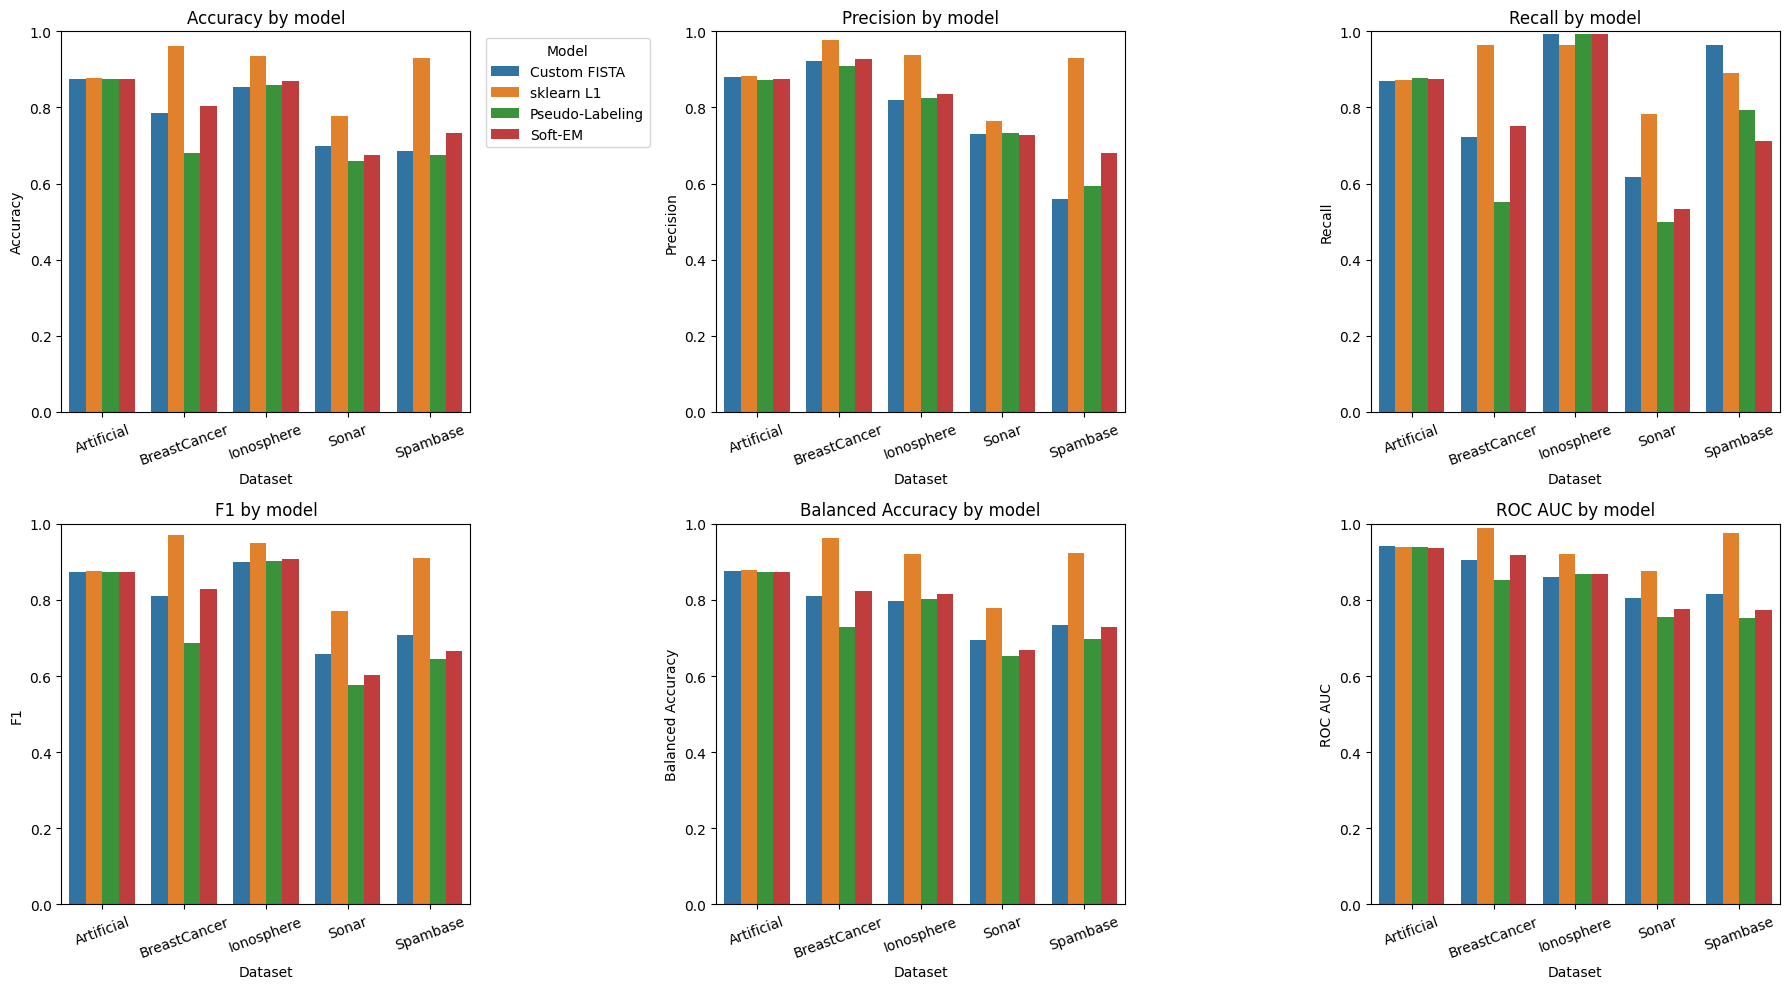

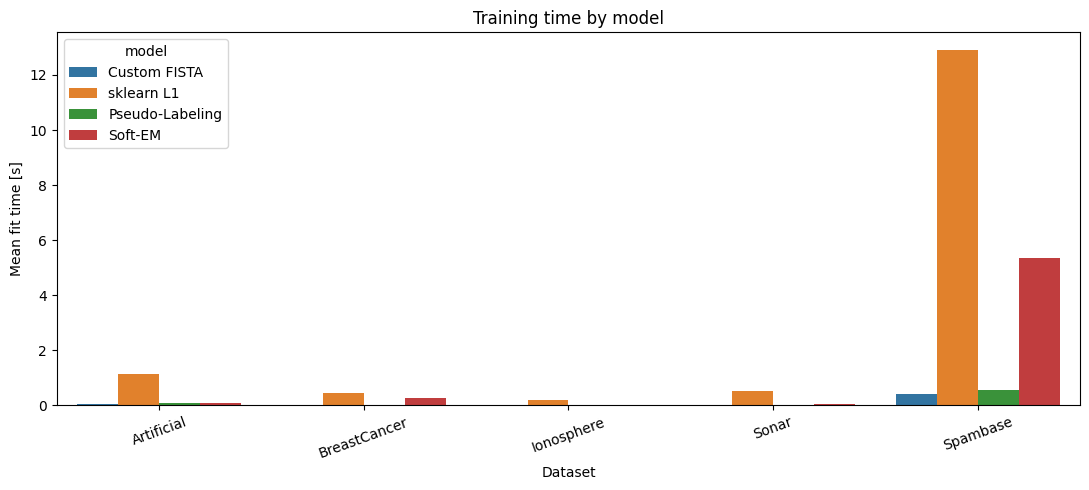

In [35]:
metric_specs = [
    ("accuracy_mean", "Accuracy"),
    ("precision_mean", "Precision"),
    ("recall_mean", "Recall"),
    ("f1_mean", "F1"),
    ("balanced_accuracy_mean", "Balanced Accuracy"),
    ("roc_auc_mean", "ROC AUC"),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, (metric_col, metric_name) in enumerate(metric_specs):
    sns.barplot(
        data=comparison_summary_df,
        x="dataset",
        y=metric_col,
        hue="model",
        hue_order=model_order,
        ax=axes[i],
    )
    axes[i].set_title(f"{metric_name} by model")
    axes[i].set_xlabel("Dataset")
    axes[i].set_ylabel(metric_name)
    axes[i].set_ylim(0.0, 1.0)
    axes[i].tick_params(axis="x", rotation=20)
    if i != 0:
        axes[i].get_legend().remove()

axes[0].legend(title="Model", bbox_to_anchor=(1.02, 1.0), loc="upper left")
plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 5))
sns.barplot(
    data=comparison_summary_df,
    x="dataset",
    y="fit_time_mean",
    hue="model",
    hue_order=model_order,
)
plt.title("Training time by model")
plt.xlabel("Dataset")
plt.ylabel("Mean fit time [s]")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### Sklearn comparison: agreement and confusion matrices
This step visualizes pairwise prediction agreement and confusion matrices for one demo split.

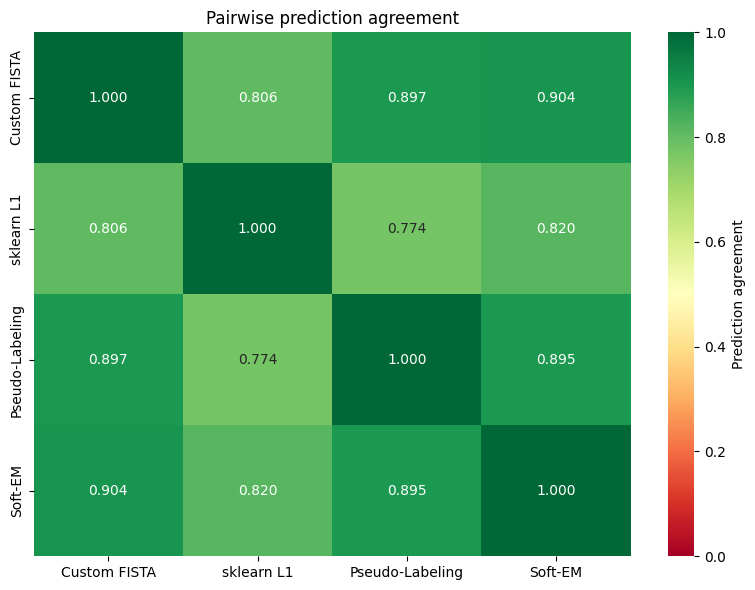

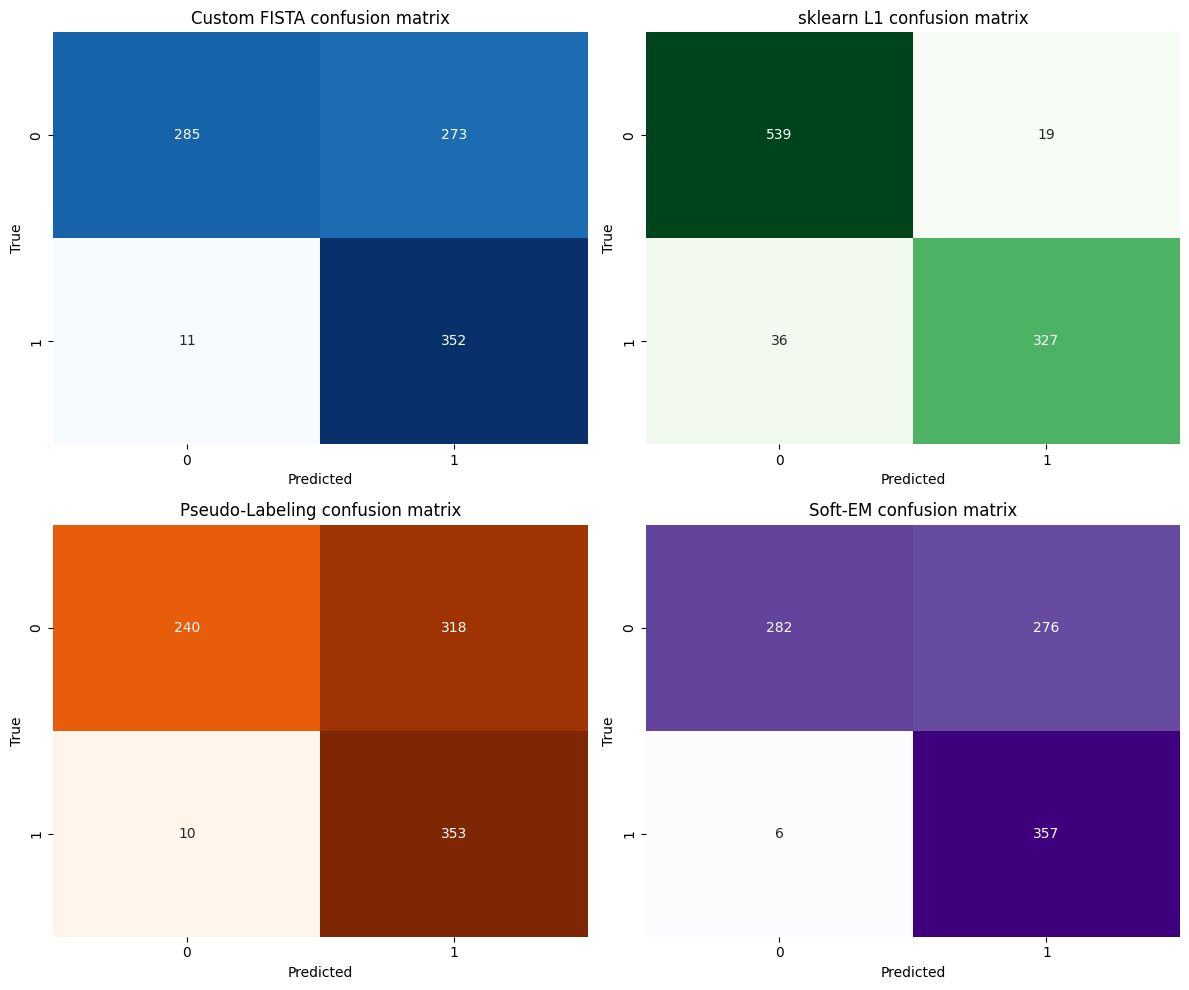

In [36]:
agreement_matrix = pd.DataFrame(1.0, index=model_order, columns=model_order, dtype=float)
for row in agreement_summary_df.itertuples(index=False):
    agreement_matrix.loc[row.model_a, row.model_b] = row.agreement_mean
    agreement_matrix.loc[row.model_b, row.model_a] = row.agreement_mean

plt.figure(figsize=(8, 6))
sns.heatmap(
    agreement_matrix,
    annot=True,
    fmt=".3f",
    cmap="RdYlGn",
    vmin=0,
    vmax=1,
    cbar_kws={"label": "Prediction agreement"},
)
plt.title("Pairwise prediction agreement")
plt.tight_layout()
plt.show()

if demo_case is not None:
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()
    cmaps = ["Blues", "Greens", "Oranges", "Purples"]

    for idx, model_name in enumerate(model_order):
        cm = confusion_matrix(
            demo_case["y_test"],
            demo_case["preds"][model_name],
            labels=[0, 1],
        )
        sns.heatmap(cm, annot=True, fmt="d", cmap=cmaps[idx], cbar=False, ax=axes[idx])
        axes[idx].set_title(f"{model_name} confusion matrix")
        axes[idx].set_xlabel("Predicted")
        axes[idx].set_ylabel("True")

    plt.tight_layout()
    plt.show()

# Running on new data

In [37]:
def run_on_custom_data(csv_path, target_column):
    """Load CSV, preprocess features, and train UnlabeledLogReg."""
    print(f"Loading data from {csv_path}")
    df = pd.read_csv(csv_path)

    X_new = df.drop(columns=[target_column]).values
    y_new = df[target_column].values

    X_new = SimpleImputer(strategy="mean").fit_transform(X_new)
    X_new = StandardScaler().fit_transform(X_new)

    model = UnlabeledLogReg(model=FISTA(lambdas=[0.01]), method="em")
    model.fit(X_new, y_new)
    print("Model trained")
    return model